In [3]:
file_path = "../outputs/"

# Analysis Excercise 01.1

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2   # necessary to confront the chi-squared distribution with the data

In [5]:
# Extract the data from the output files
x, sum_prog, err_prog, var_prog, err_var_prog = np.loadtxt(file_path + "01_1_means_and_variances.dat", unpack=True)

## Excercise 01.1.1: mean and its uncertainty

First I plot the value of the mean as a function of the number of throws: the plot shows that the mean approaches the expected value (in this case 0.5) for a large number of throws. The bars represent the uncertainty on the current value of the mean. Note that the error decreases with the increasing of the number of throws, as expected from the central limit theorem.

The value of the mean is compatible with the expected value.

The plot shows the values of the mean minus the expected value, therefore the expected value of the quantity $<r>- 0.5$ is zero. 

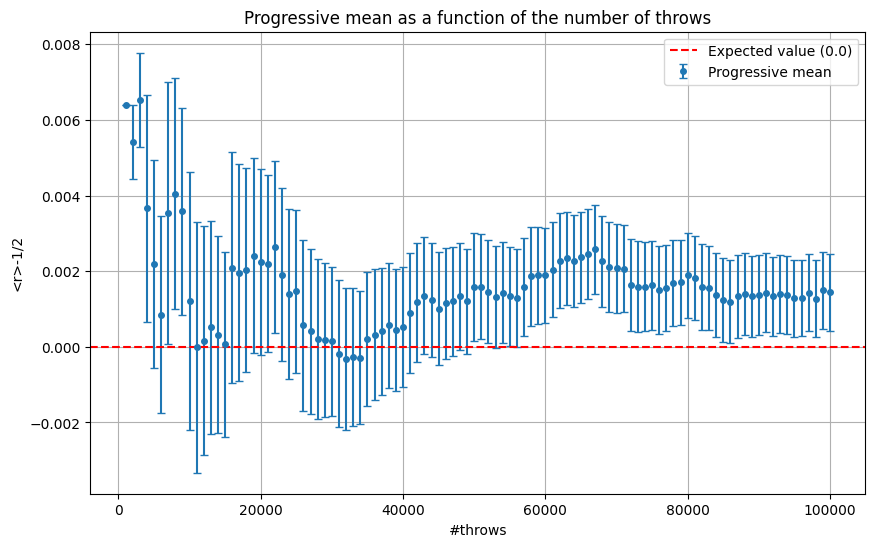

In [6]:
plt.figure(figsize=(10, 6))

plt.errorbar(x, sum_prog - 0.5, yerr=err_prog, label = 'Progressive mean', fmt='o', markersize=4, capsize=3)
plt.axhline(0, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('#throws')
plt.ylabel('<r>-1/2')
plt.title('Progressive mean as a function of the number of throws')
plt.grid(True)
plt.legend()
plt.show()

Therefore the estimate for the mean is given by the last row of the file and is shown below. Note that this is compatible with the true value $0.5$ within 2 standard deviations.

In [7]:
mean_final_estimate = sum_prog[-1]
mean_final_error = err_prog[-1]
print(f"===== Final estimation of the mean: {mean_final_estimate:.4f} ± {mean_final_error:.4f} =====")

===== Final estimation of the mean: 0.5014 ± 0.0010 =====


## Excercise 01.1.2: variance and its uncertainty

Here I plot the value of the variance as a function of the number of throws: the plot shows that the variance approaches the expected value (in this case 1/12) for a large number of throws. The bars represent the uncertainty on the current value of the variance. Note that the error decreases with the increasing of the number of throws.

The value of the variance is compatible with the expected value.

The plot shows the values of the variance minus the expected value, therefore the expected value of the quantity $(<r>- 0.5)^2-1/12$ is zero.

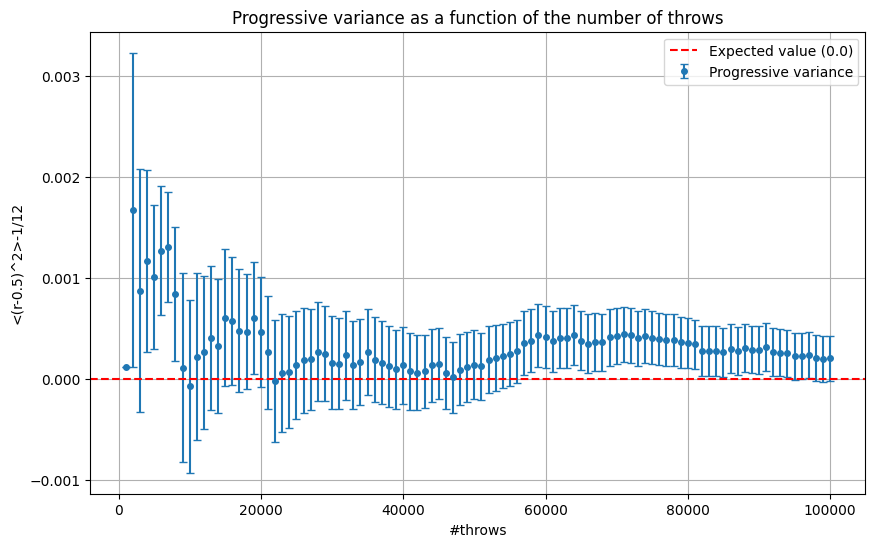

In [8]:
plt.figure(figsize=(10, 6))

plt.errorbar(x, var_prog - 1.0/12.0, yerr=err_var_prog, label = 'Progressive variance', fmt='o', markersize=4, capsize=3)
plt.axhline(0, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('#throws')
plt.ylabel('<(r-0.5)^2>-1/12')
plt.title('Progressive variance as a function of the number of throws')
plt.grid(True)
plt.legend()
plt.show()

Therefore the estimate for the variance is given by the last row of the file and is shown below. Note that this is compatible with the true value $1/12 \approx 0.08333$ within 1 standard deviations.

In [9]:
variance_final_estimate = var_prog[-1]
variance_final_error = err_var_prog[-1]
print(f"===== Final estimation of the variance: {variance_final_estimate:.5f} ± {variance_final_error:.5f} =====")

===== Final estimation of the variance: 0.08354 ± 0.00022 =====


## Excercise 01.1.3: compatibility of generated numbers with uniform distribution

Here I evaluate the compatibility of the distribution of numbers generated with the uniform distribution. I use the $\chi^2$ test. Therefore I calculated 1000 values of $\chi^2$ and evaluated the mean of these values, that for a $\chi^2$ distribution corresponds with the umber of the degrees of freedom of the distribution.

In the large sample limit the distribution of the quantity

$$\chi^2 = \sum_{i} \frac{\left( O_i - E_i \right)^2}{E_i}$$

approaches a $\chi^2$ distribution with $n_{Bins} - 1$ degrees of freedom, where $n_{Bins}$ is the number of bins used in each one of the tests I performed, in this case $n_{Bins}=100$.

As shown in the following I obtain a mean of the $\chi^2$ calculated very close to $n_{Bins} - 1$.

Then I show the $\chi^2$ distribution with $n_{Bins} - 1$ degrees of freedom superimposed on the distribution of the obtained values. The theoretical curve describes very well the distribution of the experimental values.

In [11]:
# Import the chi-squared values obtained from the test of uniformity
chi_squared = np.loadtxt(file_path+"01_1_chi_squared.dat")

In [12]:
# Calculate the mean of the chi-squared values
mean_chi_squared=np.mean(chi_squared)
print(f"===== Mean of chi-squared values: {mean_chi_squared} =====")

===== Mean of chi-squared values: 99.144594 =====


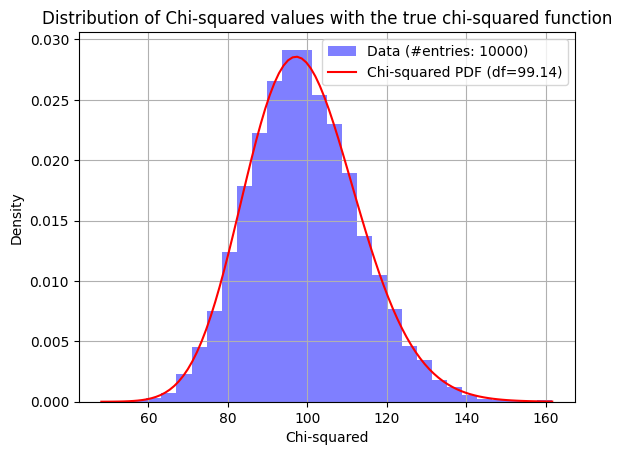

In [13]:
# Plot together the histogram and the chi-squared distribution
n_entries = len(chi_squared)
plt.hist(chi_squared, bins=30, density=True, alpha=0.5, color='blue', label=f'Data (#entries: {n_entries})')
x = np.linspace(min(chi_squared), max(chi_squared), 100)
plt.plot(x, chi2.pdf(x, df=mean_chi_squared), color='red', label=f'Chi-squared PDF (df={mean_chi_squared:.2f})')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.title('Distribution of Chi-squared values with the true chi-squared function')
plt.grid(True)
plt.legend()


# Analysis Excercise 01.2

In the next analysis I am going to show the distribution values of the mean of random variables: the central limit theorem assures that if $N$ random variables are indipendent and identically distributed according to a $pdf$ with mean $\mu$ and FINITE variance $\sigma^2$, in the limit for $N\rightarrow \infty$ the sum of these variables is distributed according to a Gaussian with mean $\mu$, and variance $\sigma^2/N$. The Gaussian distribution is therefore a so called basin of attraction in the $pdf$ space.

The Lorentzian distribution does not satisfy the hypoteses of the central limit theorem, because it does not have finite variance. Therefore the sum of Lorentzian random variables is not guaranteed to distribute according to a Gaussian (and in fact it doesn't). However, the basin of attraction for the sum of Lorentzian random variables is itself a Lorentzian distribution.

In the figures below I show the distribution of the sum of uniform, exponential and Lorentzian random variables with increasing number of terms in the sum ($N$). The last picture shows the distribution of the sum of 100 random variables. One can see that for the uniform and exponential distribution (whose have finite variance) the sum of 100 variables is well fitted by a Gaussian distribution. The Lorentzian sum is instead well fitted by a Lorentzian distribution.

In [15]:
# Import the data for the three different distributions
unif_1, unif_2, unif_10, unif_100 = np.loadtxt(file_path+"01_2_random_uniform.dat", unpack=True)
exp_1, exp_2, exp_10, exp_100 = np.loadtxt(file_path+"01_2_random_exponential.dat", unpack=True)
lor_1, lor_2, lor_10, lor_100 = np.loadtxt(file_path+"01_2_random_Lorentzian.dat", unpack=True)

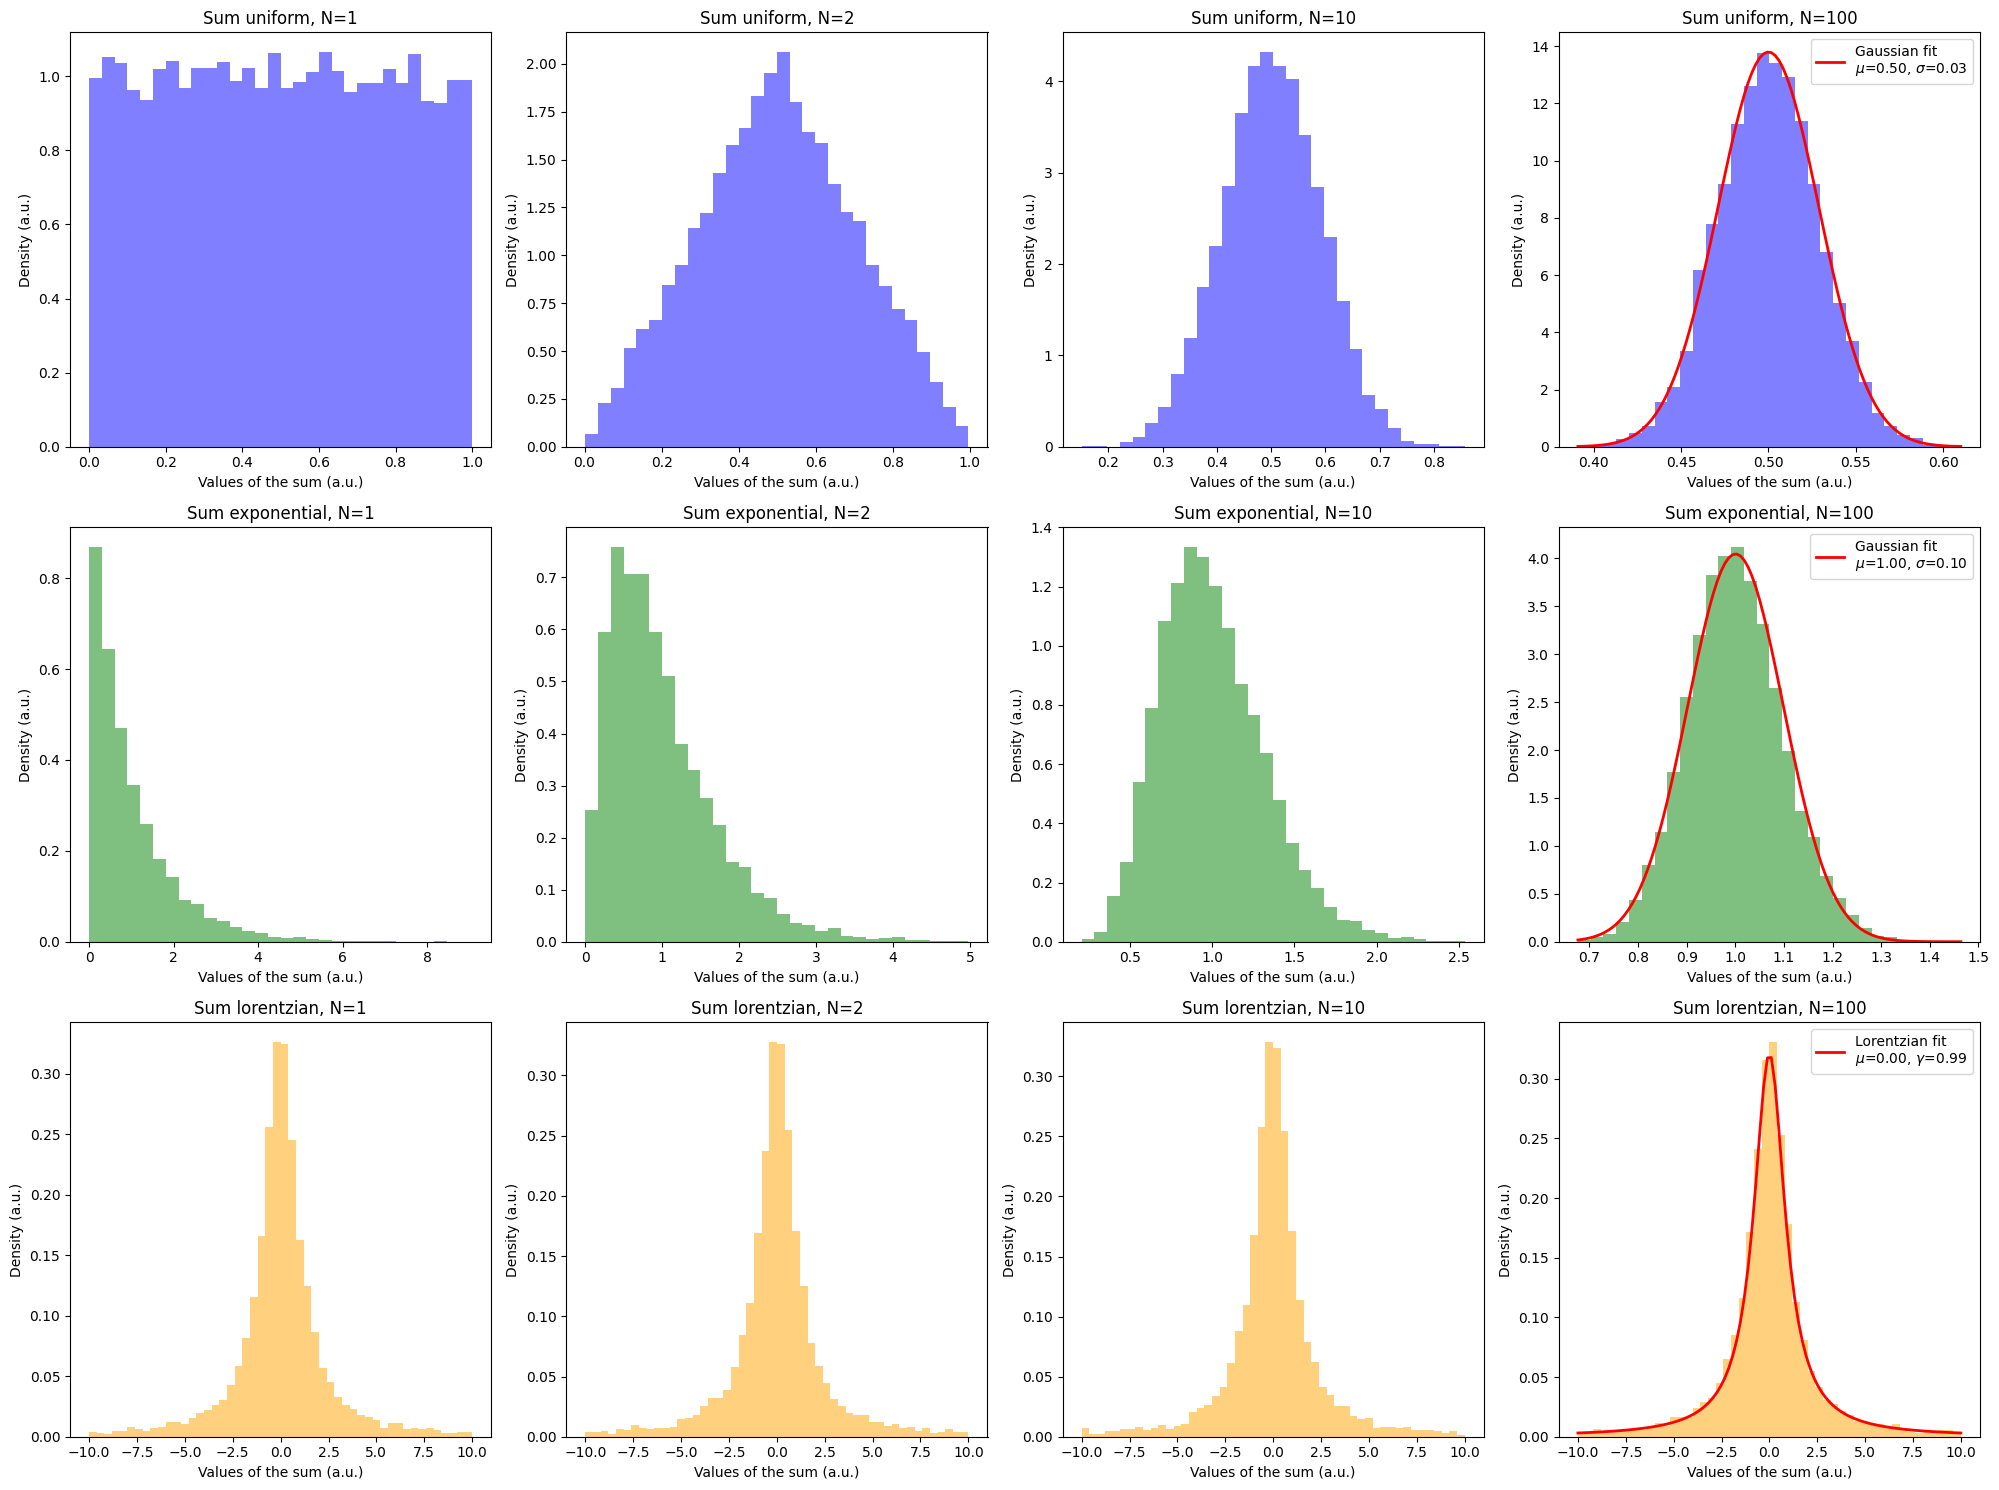

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy

N_values = [1, 2, 10, 100]

uniforms = [unif_1, unif_2, unif_10, unif_100]
exponentials = [exp_1, exp_2, exp_10, exp_100]
lorentzians = [lor_1, lor_2, lor_10, lor_100]

fig, axs = plt.subplots(3, 4, figsize=(20, 15))

for i in range(len(N_values)):
    # ---------------------------------------------------------
    # First row: Sum uniform
    # ---------------------------------------------------------
    axs[0, i].hist(uniforms[i], bins=30, density=True, alpha=0.5, color='blue')
    axs[0, i].set_title(f'Sum uniform, N={N_values[i]}')
    axs[0, i].set_xlabel('Values of the sum (a.u.)')
    axs[0, i].set_ylabel('Density (a.u.)')
    
    if i == 3: # Gaussian fit for N=100
        mu_unif, std_unif = norm.fit(uniforms[i])
        x_unif = np.linspace(min(uniforms[i]), max(uniforms[i]), 100)
        p_unif = norm.pdf(x_unif, mu_unif, std_unif)
        axs[0, i].plot(x_unif, p_unif, 'red', linewidth=2, label=f'Gaussian fit\n$\mu$={mu_unif:.2f}, $\sigma$={std_unif:.2f}')
        axs[0, i].legend()

    
    # ---------------------------------------------------------
    # Second row: Sum exponential
    # ---------------------------------------------------------
    axs[1, i].hist(exponentials[i], bins=30, density=True, alpha=0.5, color='green')
    axs[1, i].set_title(f'Sum exponential, N={N_values[i]}')

    axs[1, i].set_xlabel('Values of the sum (a.u.)')
    axs[1, i].set_ylabel('Density (a.u.)')
    
    if i == 3: # Gaussian fit for N=100
        mu_exp, std_exp = norm.fit(exponentials[i])
        x_exp = np.linspace(min(exponentials[i]), max(exponentials[i]), 100)
        p_exp = norm.pdf(x_exp, mu_exp, std_exp)
        axs[1, i].plot(x_exp, p_exp, 'red', linewidth=2, label=f'Gaussian fit\n$\mu$={mu_exp:.2f}, $\sigma$={std_exp:.2f}')
        axs[1, i].legend()
    
    # ---------------------------------------------------------
    # Third row: Sum lorentzian
    # ---------------------------------------------------------
    # IL FIX: Aggiungiamo range=(-10, 10) per tagliare gli outlier grafici
    axs[2, i].hist(lorentzians[i], bins=50, range=(-10, 10), density=True, alpha=0.5, color='orange')
    axs[2, i].set_title(f'Sum lorentzian, N={N_values[i]}')

    axs[2, i].set_xlabel('Values of the sum (a.u.)')
    axs[2, i].set_ylabel('Density (a.u.)')
    
    if i == 3: # Lorentzian fit for N=100
        # Calculating the fit on the whole range of data to get the correct parameters of the distribution
        loc_lor, scale_lor = cauchy.fit(lorentzians[i])
        

        x_lor = np.linspace(-10, 10, 100) # Limiting the x range to visualize the distribution better
        p_lor = cauchy.pdf(x_lor, loc_lor, scale_lor)
        
        axs[2, i].plot(x_lor, p_lor, 'red', linewidth=2, label=f'Lorentzian fit\n$\mu$={loc_lor:.2f}, $\gamma$={scale_lor:.2f}')
        axs[2, i].legend()
        

plt.tight_layout()
plt.show()

### Sum of uniform

The mean of uniformly distrbuted variables in $[0,1)$ is $\mu_U = 0.5$, and the standard deviation is $\sigma_U = \sqrt{1/12} \approx 0.29$. We expect the sum of $N = 100$ uniformly distributed variables to distribute according to a Gaussian with mean $\mu_{MEAN} = 0.5$ and standard deviation $\sigma_{MEAN}=\sigma_U/\sqrt{N} = \sigma_U/10 \approx 0.03$.

This result is what's found with the gaussian fit shown in the last picture (in the legend there are the stats relative to the gaussian fit).

### Sum of exponential

The exponential variables are generated with a parameter $\lambda=1.0$, therefore the mean of the distribution is $\mu_E=\lambda=1$ and its standard deviation is $\sigma_E = \lambda = 1.0$.

From the central limit theorem one should expect that the sum of $N=100$ of these variables distribute according to a Gaussian with mean $\mu_{MEAN}=1.0$ and standard deviation $\sigma_{MEAN}=\sigma_E/\sqrt{N} = \sigma_E/10 = 0.1$, that is exactly what the Gaussian fit shows.

### Sum of Lorentzian

In the case of the Lorentzian distribution one cannot apply the central limit theorem. However, the Lorentzian distribution is a stable distribution (it is invariant under Fourier's convolution) and therefore is a candidate basin of attraction. The picture above shows that the Lotentzian distribution is in fact the basin of attraction for the mean of Lorentzian distributed variables.

The mean $\mu$ and scale $\Gamma$ of the distribution of the means is equal to the mean and scale of the distribution of the single variables (that are in this case generated with $\mu=0$ and $\Gamma=1$) and that is exactly what the stats in the picture legend show.

# Analysis Excercise 01.3

For this excercise I simulated the Buffon's experiment for the estimation of $\pi$. I set the parameters $d=10$ (distance between the lines) and $L=5$ (length of the needle).

In the simulation I used the following logic:

          - for each throw I extract a random number between 0 and d/2 (distance of the centre of the needle from the closest line)
          - I extract the coordinates of one end of the needle: angle needs to be uniformly distributed:
                  -> I extract 2 uniformly distributed variables dx and dy between 0 and 1
                  -> calculate the norm dx^2+dy^2
                  -> if norm is <= 1 I accept the throw
             This samples the unit circle uniformly and therefore the accepted points have an angle that is uniformly distributed
          - I calculate the norm of (dx, dy)
          - I compute the sine of the angle between the needle and the lines as dy/norm 
          - If the distance of the centre of the needle from the closest line is smaller than L/2*sin(theta) then I count a crossing.

This logic avoids the generation of an angle to simulate the position and orientation of the needle, that would require the use of $\pi$ in order to set the boundaries of extraction for the angle.

I then calculated the $\pi$ value for each block and the related uncertainty. The plot below shows the progressive mean with the error bar.

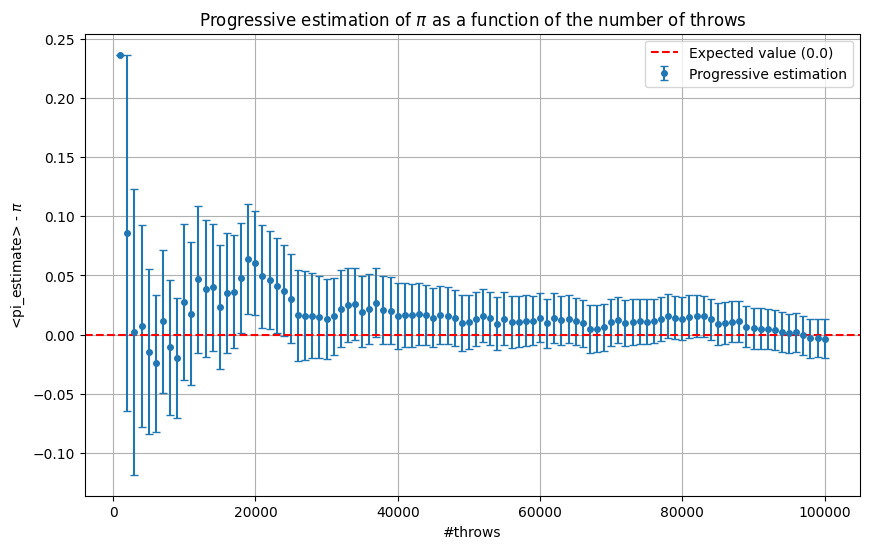

In [17]:
x, pi_values, errs = np.loadtxt(file_path+"01_3_pi_estimate.dat", unpack=True)

plt.figure(figsize=(10, 6))

plt.errorbar(x, pi_values - np.pi, yerr=errs, label = 'Progressive estimation', fmt='o', markersize=4, capsize=3)
plt.axhline(0, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('#throws')
plt.ylabel('<pi_estimate> - $\pi$')
plt.title('Progressive estimation of $\pi$ as a function of the number of throws')
plt.grid(True)
plt.legend()
plt.show()

The plot above shows that the estimator value approacher $\pi$ as the number of throws increases, and is therefore a good estimator.

An estimation of $\pi$ that includes all the measurements is given by the last row in the files and is shown below.

In [18]:
pi_final_estimate = pi_values[-1]
pi_final_error = errs[-1]
print(f"===== Final estimation of pi: {pi_final_estimate:.6f} ± {pi_final_error:.6f} =====")

===== Final estimation of pi: 3.138210 ± 0.016272 =====
